In [4]:
import gensim.downloader as api
model = api.load("glove-wiki-gigaword-50")


In [11]:
vector = model['tower']
print(vector)

vectors = model.most_similar('king')
print (vectors)


[ 1.1474e+00  1.1811e+00  7.4556e-01 -5.9101e-02  5.0499e-01 -7.0449e-01
 -3.2136e-01 -4.5390e-01 -4.5763e-01 -7.5341e-01 -3.3511e-01 -2.4975e-02
 -5.0192e-01  6.3773e-01 -8.3059e-01  8.3565e-01 -2.4701e-01  3.2421e-01
 -1.1103e+00 -2.1335e-02  6.8717e-01 -3.9340e-01 -1.6390e+00 -5.0493e-01
 -1.6684e-01 -6.7649e-01 -3.1798e-01  8.8503e-01 -3.1552e-02 -1.5608e-01
  1.9805e+00 -1.1870e+00  8.3342e-01 -1.8369e-01 -2.6691e-01  1.1619e-01
  1.1023e+00 -3.5937e-01  2.5015e-02 -4.0615e-02  3.0681e-01 -4.1076e-01
  8.4586e-02  2.2475e-01 -5.0955e-01  6.5819e-01 -1.2432e-01 -1.4039e+00
  1.6178e-04 -5.2529e-01]
[('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746229767799377), ('emperor', 0.7736247777938843), ('son', 0.766719400882721), ('uncle', 0.7627150416374207), ('kingdom', 0.7542160749435425), ('throne', 0.7539913654327393), ('brother', 0.7492411732673645), ('ruler', 0.7434253692626953)]


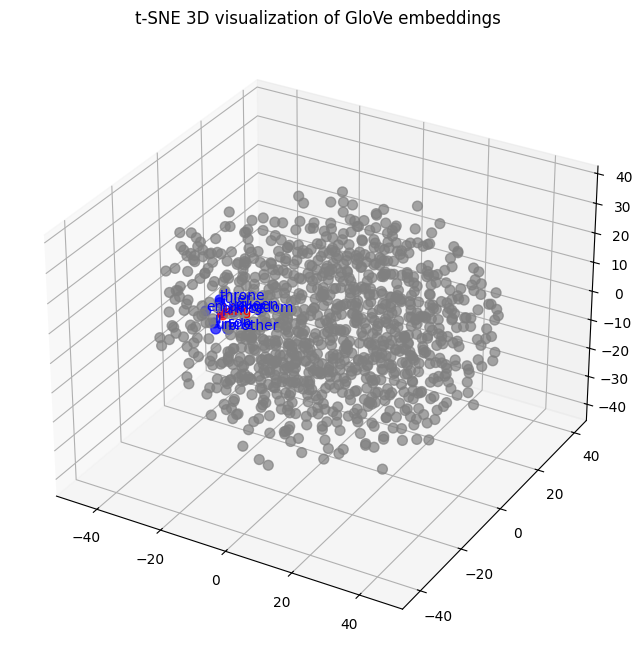

In [15]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Get the 10 most similar words to 'king'
nearest = model.most_similar('king', topn=10)
nearest_words = [w for w, _ in nearest]
nearest_vectors = [model[w] for w in nearest_words]

# Select a random sample of 200 words from the vocab (excluding nearest)
all_words = set(model.index_to_key)
sample_words = list(all_words - set(nearest_words) - {'king'})
np.random.seed(42)
sample_words = np.random.choice(sample_words, 1000, replace=False)
sample_vectors = [model[w] for w in sample_words]

# Combine for tSNE: king, nearest, and random sample
words = ['king'] + nearest_words + list(sample_words)
vectors = [model['king']] + nearest_vectors + sample_vectors
vectors = np.array(vectors)  # Convert list to numpy array

# tSNE to 3D
tsne = TSNE(n_components=3, random_state=42, perplexity=30)
embeddings_3d = tsne.fit_transform(vectors)

# Color: red for king, blue for nearest, gray for others
colors = ['red'] + ['blue']*len(nearest_words) + ['gray']*len(sample_words)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(embeddings_3d[:,0], embeddings_3d[:,1], embeddings_3d[:,2], c=colors, s=50, alpha=0.7)

# Annotate king and nearest
for i, word in enumerate(words[:11]):
    ax.text(embeddings_3d[i,0], embeddings_3d[i,1], embeddings_3d[i,2], word, color=colors[i], fontsize=10)

ax.set_title('t-SNE 3D visualization of GloVe embeddings')
plt.show()